In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df=pd.read_csv('/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
#checking dimensions of the data
print(df.shape)

(10000, 14)


In [8]:
#information related tot the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
#checking for no. of duplicate values
df.duplicated().sum()

0

In [11]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [12]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [13]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [14]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [15]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
#performing one-hot encoding on Geography and Gender columns
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [18]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [19]:
from sklearn.model_selection import train_test_split

In [23]:
X=df.drop(columns=['Exited'])
y=df['Exited']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [26]:
X_train.shape

(8000, 11)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [45]:
#importing libraries
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [59]:
#defining the model
model = Sequential() #using sequential stack of layers

model.add(Dense(11,activation='relu',input_dim=11)) #input layer followed by 1 hidden layer
model.add(Dense(11,activation='relu'))              #second hidden layer
model.add(Dense(1,activation='sigmoid'))            #output layer

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
#summary of the model
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.compile(loss='binary_crossentropy',optimizer='Adam', metrics=['accuracy'])

In [62]:
history = model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7963 - loss: 0.5100 - val_accuracy: 0.7975 - val_loss: 0.4616
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7933 - loss: 0.4616 - val_accuracy: 0.8012 - val_loss: 0.4408
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8097 - loss: 0.4339 - val_accuracy: 0.8138 - val_loss: 0.4279
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8110 - loss: 0.4373 - val_accuracy: 0.8169 - val_loss: 0.4161
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8237 - loss: 0.4168 - val_accuracy: 0.8256 - val_loss: 0.4068
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8332 - loss: 0.4016 - val_accuracy: 0.8281 - val_loss: 0.3985
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8323 - loss: 0.4022 - val_accuracy: 0.8250 - val_loss: 0.3930
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8345 - loss: 0.3951 - val_accu

In [52]:
#check weights of layer
model.layers[0].get_weights()

[array([[-0.45106378, -0.00201305, -0.0131346 , -0.02641875,  0.00574976,
         -0.04131793, -0.12391946,  0.24737188, -0.08552933, -0.48923957,
          0.29387873],
        [ 0.01674214, -0.8480031 , -0.1384801 ,  0.6032933 , -1.1054757 ,
         -1.1315299 ,  0.35011286, -0.6791916 ,  0.23335986,  0.8814777 ,
         -0.22696741],
        [-0.267771  ,  0.11171392,  0.27067253,  0.17265412, -0.11199007,
          0.28874987, -0.13071497, -0.29831645,  0.12165263,  0.27853075,
          0.4570305 ],
        [-0.10852113,  0.00902378, -0.40882838, -0.2183924 , -0.6708657 ,
          0.62236   ,  0.2523468 , -0.00532339, -0.29076684,  0.10387129,
         -1.1084543 ],
        [-0.68811077, -0.01599121,  1.7379967 , -0.0721433 ,  0.53306663,
         -0.02439997,  0.0339261 , -0.3178831 , -1.3087703 ,  0.07066448,
         -0.27919486],
        [ 0.01314728, -0.07447622,  0.24731603,  0.0716451 ,  0.05543475,
         -0.4583959 ,  0.7167424 , -0.5407601 , -0.26222402,  0.1554971

In [53]:
#check weights of layer
model.layers[1].get_weights()

[array([[-0.46224418,  0.06332057, -0.1195716 , -0.3147715 , -0.66915804,
         -0.38066888, -0.06614078, -0.07848258,  0.33051902,  0.17737038,
          0.30482277],
        [ 0.33564264, -0.5706891 , -0.77566886,  0.46312132,  0.11846312,
         -0.07472013,  0.9564706 , -0.9642003 , -0.68643874,  1.1052672 ,
         -0.22404125],
        [-0.01763907, -0.30946976, -0.03586188, -0.47471094, -0.78377527,
          0.664942  ,  0.12581389,  1.0870724 , -0.48614863,  0.2568174 ,
         -0.5690295 ],
        [ 0.27594054, -0.4923662 , -0.26330423, -0.96698934,  0.56986773,
         -0.568736  ,  1.0464233 , -0.56543803, -0.4235899 , -0.18319131,
         -0.15725595],
        [ 0.3865834 , -0.06584889, -2.183497  ,  0.6216956 , -0.25515115,
         -0.27376842,  0.35102028, -0.00768375, -0.274248  ,  0.71401083,
          0.30707946],
        [-0.3172675 ,  0.44348294,  0.20427501,  0.43210244,  0.35159507,
         -0.15076883,  0.45407045,  0.46150988,  0.2457368 ,  0.1226877

In [55]:
#check weights of layer
model.layers[2].get_weights()

[array([[-0.67647326],
        [ 1.0889729 ],
        [ 1.6171544 ],
        [ 1.1963215 ],
        [ 1.2664967 ],
        [ 1.2620779 ],
        [-0.51335645],
        [ 1.210939  ],
        [ 1.0261523 ],
        [-0.29144448],
        [ 0.865663  ]], dtype=float32),
 array([-0.18535966], dtype=float32)]

In [56]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [57]:
y_pred = np.where(y_log>0.5,1,0)

In [58]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.864

In [65]:
import matplotlib.pyplot as plt

In [66]:
history.history

{'accuracy': [0.7971875071525574,
  0.7978125214576721,
  0.8118749856948853,
  0.8176562786102295,
  0.8235937356948853,
  0.8274999856948853,
  0.8331249952316284,
  0.8376562595367432,
  0.8426562547683716,
  0.8457812666893005,
  0.8481249809265137,
  0.8504687547683716,
  0.85546875,
  0.8540624976158142,
  0.8575000166893005,
  0.8578125238418579,
  0.8603125214576721,
  0.8595312237739563,
  0.8618749976158142,
  0.8615624904632568,
  0.8621875047683716,
  0.8595312237739563,
  0.8623437285423279,
  0.860156238079071,
  0.8606250286102295,
  0.860156238079071,
  0.8620312213897705,
  0.8609374761581421,
  0.8623437285423279,
  0.8623437285423279,
  0.8637499809265137,
  0.8634374737739563,
  0.862500011920929,
  0.8639062643051147,
  0.8631250262260437,
  0.8614062666893005,
  0.8642187714576721,
  0.8645312786102295,
  0.8656250238418579,
  0.8650000095367432,
  0.864062488079071,
  0.8634374737739563,
  0.8646875023841858,
  0.8648437261581421,
  0.8646875023841858,
  0.865312

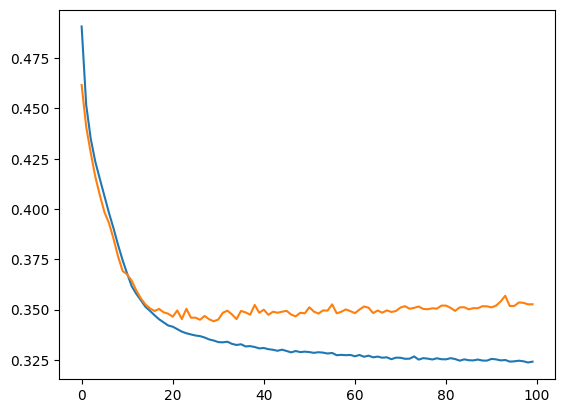

In [68]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

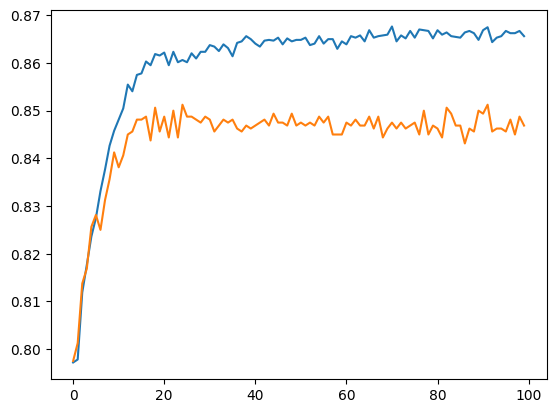

In [71]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])